In [3]:
import pandas as pd
#Load the Dataset
df = pd.read_csv('online_retail_II.csv')
#FirstLook
print(df.shape)# rows and columns
print(df.dtypes)#Data Types
print(df.head())#first five rows
print(df.isnull().sum())#check missing values

(1067371, 8)
Invoice            str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
Price          float64
Customer ID    float64
Country            str
dtype: object
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  
In

In [4]:
import pandas as pd 
df = pd.read_csv('online_retail_II.csv', encoding='unicode_escape')

print("Shape Before cleaning",df.shape)
# Fix 1: Drop missing customers ID
df = df.dropna(subset = ['Customer ID'])
print("After Dropping Null Customers ID:",df.shape)
#fix 2: Remove cancel invoice
df = df[~df['Invoice'].astype(str).str.startswith('C')]
print("After Removing Cancellations:", df.shape)
#fix 3: Remove negative/zero Quantity and Price
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0 ]
print("After Removing bad Quantity and Price: ",df.shape)
#fix 4: Drops Duplicates
df = df.drop_duplicates()
print ("After Removing Duplicates: ",df.shape)
#fix 5a: Fix data types
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Customer ID'] = df['Customer ID'].astype(int)
#fix 5b: add TotalPrice Column
df['TotalPrice'] = df['Quantity'] * df['Price']
print("\n✅ Cleaning done!")
print("Final shape:", df.shape)
print(df.head())

Shape Before cleaning (1067371, 8)
After Dropping Null Customers ID: (824364, 8)
After Removing Cancellations: (805620, 8)
After Removing bad Quantity and Price:  (805549, 8)
After Removing Duplicates:  (779425, 8)

✅ Cleaning done!
Final shape: (779425, 9)
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  TotalPrice  
0 2009-12-01 07:45:00   6.95        13085  United Kingdom        83.4  
1 2009-12-01 07:45:00   6.75        13085  United Kingdom        81.0  
2 2009-12-01 07:45:00   6.75        13085  United Kingdom        81.0  
3 2009-12-01 07:45:00   2.10     

In [17]:
import pandas as pd

# Reference date: the day "after" the last transaction 
# We use this to calculate how many days ago each customer last bought
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Reference date:", reference_date)

# Calculate RFM per customer 
rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate',  lambda x: (reference_date - x.max()).days),
    Frequency = ('Invoice',      'nunique'),   # unique invoices = unique orders
    Monetary  = ('TotalPrice',   'sum')
).reset_index()

print("\nRFM table shape:", rfm.shape)
print("\nFirst 5 rows:")
print(rfm.head())

print("\nRFM summary stats:")
print(rfm.describe().round(2))

Reference date: 2011-12-10 12:50:00

RFM table shape: (5878, 4)

First 5 rows:
   Customer ID  Recency  Frequency  Monetary
0        12346      326         12  77556.46
1        12347        2          8   4921.53
2        12348       75          5   2019.40
3        12349       19          4   4428.69
4        12350      310          1    334.40

RFM summary stats:
       Customer ID  Recency  Frequency   Monetary
count      5878.00  5878.00    5878.00    5878.00
mean      15315.31   201.33       6.29    2955.90
std        1715.57   209.34      13.01   14440.85
min       12346.00     1.00       1.00       2.95
25%       13833.25    26.00       1.00     342.28
50%       15314.50    96.00       3.00     867.74
75%       16797.75   380.00       7.00    2248.30
max       18287.00   739.00     398.00  580987.04


In [7]:
import numpy as np

# Log-transform to reduce skew — makes clustering more accurate
rfm['Recency_log']   = np.log1p(rfm['Recency'])
rfm['Frequency_log'] = np.log1p(rfm['Frequency'])
rfm['Monetary_log']  = np.log1p(rfm['Monetary'])

# Verify the new columns
print(rfm[['Customer ID','Recency','Recency_log',
           'Frequency','Frequency_log',
           'Monetary','Monetary_log']].head())

   Customer ID  Recency  Recency_log  Frequency  Frequency_log  Monetary  \
0        12346      326     5.789960         12       2.564949  77556.46   
1        12347        2     1.098612          8       2.197225   4921.53   
2        12348       75     4.330733          5       1.791759   2019.40   
3        12349       19     2.995732          4       1.609438   4428.69   
4        12350      310     5.739793          1       0.693147    334.40   

   Monetary_log  
0     11.258774  
1      8.501578  
2      7.611051  
3      8.396085  
4      5.815324  


In [8]:
print("Total unique customers:", len(rfm))
print("Avg days since last purchase:", rfm['Recency'].mean().round(1))
print("Avg number of orders:", rfm['Frequency'].mean().round(1))
print("Avg spend per customer: £", rfm['Monetary'].mean().round(2))


Total unique customers: 5878
Avg days since last purchase: 201.3
Avg number of orders: 6.3
Avg spend per customer: £ 2955.9


In [10]:
from sklearn.preprocessing import StandardScaler  
#use the log-Scale Columns from Step 3
features = rfm[['Recency_log' , 'Frequency_log' , 'Monetary_log']]
#scale to mean=0 and std=1
scaler=StandardScaler()
rfm_scaled = scaler.fit_transform(features)

print("Scaled shape:", rfm_scaled.shape)
print("First 3 rows:\n", rfm_scaled[:3].round(3))


Scaled shape: (5878, 3)
First 3 rows:
 [[ 0.857  1.254  3.206]
 [-2.152  0.8    1.216]
 [-0.079  0.299  0.573]]


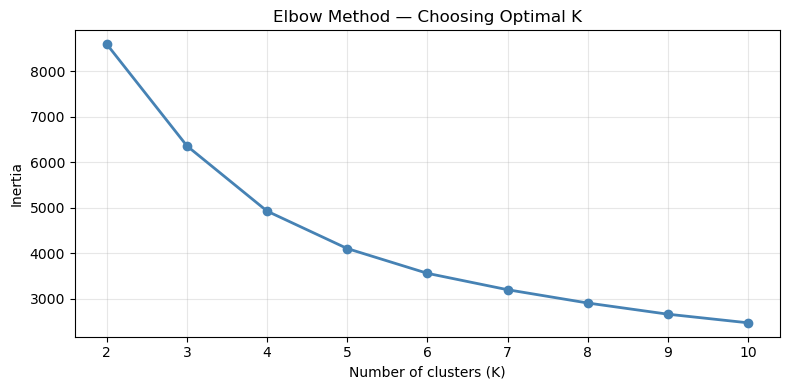

Inertia values: [8589.0, 6354.3, 4921.2, 4099.1, 3554.7, 3194.5, 2902.4, 2656.6, 2467.4]


In [12]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o', color='steelblue', linewidth=2)
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Choosing Optimal K')
plt.xticks(K_range)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Inertia values:", [round(i, 1) for i in inertia])

In [13]:
# Fit final model with K=4
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = km_final.fit_predict(rfm_scaled)

print("Customers per cluster:")
print(rfm['Cluster'].value_counts().sort_index())

Customers per cluster:
Cluster
0    1973
1    1250
2    1196
3    1459
Name: count, dtype: int64


In [14]:
# Summary: mean RFM values per cluster
cluster_summary = rfm.groupby('Cluster').agg(
    Recency_mean   = ('Recency',   'mean'),
    Frequency_mean = ('Frequency', 'mean'),
    Monetary_mean  = ('Monetary',  'mean'),
    Customer_count = ('Customer ID', 'count')
).round(1)

print(cluster_summary)

         Recency_mean  Frequency_mean  Monetary_mean  Customer_count
Cluster                                                             
0               394.9             1.4          317.1            1973
1                28.3             3.1          857.5            1250
2                27.7            19.3        10731.2            1196
3               230.1             5.1         1948.5            1459


In [15]:
# Map cluster numbers to business segment names
# (adjust the mapping based on YOUR cluster_summary output)
segment_map = {
    1: 'Champions',       # low recency, high frequency, high monetary
    2: 'Loyal Customers', # medium recency, medium frequency, medium monetary
    3: 'At Risk',         # high recency, low frequency, low monetary
    0: 'Dormant'          # very high recency, very low frequency, lowest monetary
}

rfm['Segment'] = rfm['Cluster'].map(segment_map)

print("\nSegment counts:")
print(rfm['Segment'].value_counts())

print("\nSample customers per segment:")
print(rfm[['Customer ID','Recency','Frequency','Monetary','Segment']].head(10))


Segment counts:
Segment
Dormant            1973
At Risk            1459
Champions          1250
Loyal Customers    1196
Name: count, dtype: int64

Sample customers per segment:
   Customer ID  Recency  Frequency  Monetary          Segment
0        12346      326         12  77556.46  Loyal Customers
1        12347        2          8   4921.53  Loyal Customers
2        12348       75          5   2019.40          At Risk
3        12349       19          4   4428.69        Champions
4        12350      310          1    334.40          Dormant
5        12351      375          1    300.93          Dormant
6        12352       36         10   2849.84  Loyal Customers
7        12353      204          2    406.76          Dormant
8        12354      232          1   1079.40          Dormant
9        12355      214          2    947.61          At Risk


In [16]:
rfm.to_csv('rfm_segments.csv', index=False)
print("Done! Columns:", rfm.columns.tolist())
print("Rows:", len(rfm))


Done! Columns: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'Recency_log', 'Frequency_log', 'Monetary_log', 'Cluster', 'Segment']
Rows: 5878
